# 03 - Transfer Learning with DenseNet121


In this notebook we use transfer learning with a pre-trained DenseNet121 model.
Transfer learning and the two-phase approach (freeze base → fine-tune) is covered
in Chollet (2025, Chapter 8). We use DenseNet121 specifically because it is the
architecture used in the original CheXpert paper (Irvin et al., 2019), which allows
us to compare our results directly against their baseline.

We compare this model against:
- Our baseline CNN from notebook 02 (Mean AUC: 0.865)
- Stanford baseline (Mean AUC: 0.907, Irvin et al., 2019)

Why DenseNet121?  
DenseNet121 uses dense connections where each layer receives feature maps from
all preceding layers, enabling strong feature reuse and gradient flow. This makes
it particularly effective for medical imaging tasks where subtle features matter.

## 1. Import libraries
We use Keras with TensorFlow as backend, same as last time.
`keras.applications` provides pre-trained architectures like DenseNet121
with ImageNet weights.

In [22]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub
import tensorflow as tf
import keras
from keras import layers
from keras.applications import DenseNet121

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)

TensorFlow: 2.20.0
Keras: 3.13.2


## 2. Load data and define labels

Same data pipeline as in notebook 02. We focus on the 5 clinically most important
conditions from the CheXpert competition, with the same
uncertainty label strategy:
- U-Ones for Atelectasis and Edema
- U-Zeros for Cardiomegaly, Consolidation, and Pleural Effusion

In [23]:
# Download dataset
path = kagglehub.dataset_download("ashery/chexpert")

# Load CSV files
train_df = pd.read_csv(os.path.join(path, "train.csv"))
valid_df = pd.read_csv(os.path.join(path, "valid.csv"))

# The 5 clinically most important conditions from the CheXpert competition
LABELS = ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Pleural Effusion']

# Handle uncertain labels (-1)
# U-Ones for Atelectasis and Edema, U-Zeros for the rest
u_ones = ['Atelectasis', 'Edema']
u_zeros = ['Cardiomegaly', 'Consolidation', 'Pleural Effusion']

for col in u_ones:
    train_df[col] = train_df[col].replace(-1, 1)
for col in u_zeros:
    train_df[col] = train_df[col].replace(-1, 0)

# Fill remaining NaN with 0
train_df[LABELS] = train_df[LABELS].fillna(0)
valid_df[LABELS] = valid_df[LABELS].fillna(0)

# Use only frontal images
train_df = train_df[train_df['Frontal/Lateral'] == 'Frontal']
valid_df = valid_df[valid_df['Frontal/Lateral'] == 'Frontal']

print(f"Training images: {len(train_df)}")
print(f"Validation images: {len(valid_df)}")

Training images: 191027
Validation images: 202


## 3. Data pipeline with tf.data

Same pipeline as notebook 02. Images are resized to 224x224 pixels and
normalized to [0, 1]. DenseNet121 expects RGB images of size 224x224.

In [24]:
IMG_SIZE = 224
BATCH_SIZE = 32

def load_image(img_path, labels):
    # Read and preprocess image
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0  # Normalize to [0, 1]
    return img, labels

def make_dataset(df, shuffle=True):
    # Fix image paths
    paths = df['Path'].str.replace('CheXpert-v1.0-small/', '', regex=False)
    paths = [os.path.join(path, p) for p in paths]
    labels = df[LABELS].values.astype(np.float32)

    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        dataset = dataset.shuffle(buffer_size=1000)
    dataset = dataset.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return dataset

data_augmentation_layers = [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2),
]

def augment(image, labels):
    for layer in data_augmentation_layers:
        image = layer(image)
    return image, labels

def make_dataset(df, shuffle=True, augment_data=False):
    paths = df['Path'].str.replace('CheXpert-v1.0-small/', '', regex=False)
    paths = [os.path.join(path, p) for p in paths]
    labels = df[LABELS].values.astype(np.float32)
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        dataset = dataset.shuffle(buffer_size=1000)
    dataset = dataset.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    if augment_data:
        dataset = dataset.map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return dataset

train_ds = make_dataset(train_df, shuffle=True, augment_data=True)
valid_ds = make_dataset(valid_df, shuffle=False, augment_data=False)

print("Data pipeline ready!")

Data pipeline ready!


## 4. Build transfer learning model

Following the two-phase approach described in Chollet (2025, Chapter 8):

Phase 1 - Feature extraction (frozen base):
Load DenseNet121 pre-trained on ImageNet, freeze all base layers, and train
only the new classification head. This prevents destroying the pre-trained
representations with large random gradient updates.

Phase 2 - Fine-tuning:
Unfreeze the top layers of the base model and jointly train with a very low
learning rate. This slightly adjusts the more abstract representations to
better fit our medical imaging task.

We use `include_top=False` to remove the original ImageNet classifier and
replace it with our own multi-label classification head.

In [25]:
def build_transfer_model(input_shape=(224, 224, 3), num_classes=5):
    # Load DenseNet121 pre-trained on ImageNet, without the top classifier
    base_model = DenseNet121(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )

    # Phase 1: Freeze the base model
    base_model.trainable = False

    # Build the model
    inputs = keras.Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)

    # Sigmoid output for multi-label classification
    outputs = layers.Dense(num_classes, activation='sigmoid')(x)

    model = keras.Model(inputs, outputs, name="DenseNet121_Transfer")
    return model, base_model

model, base_model = build_transfer_model()
model.summary()

print(f"\nTrainable params: {sum([tf.size(w).numpy() for w in model.trainable_weights]):,}")
print(f"Non-trainable params: {sum([tf.size(w).numpy() for w in model.non_trainable_weights]):,}")

Model: "DenseNet121_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,301,189 (27.85 MB)

 Trainable params: 263,685 (1.01 MB)

 Non-trainable params: 7,037,504 (26.85 MB)


Trainable params: 263,685
Non-trainable params: 7,037,504


## 5. Compile the model - Phase 1

We use the Adam optimizer from the course, and Binary Crossentropy as the loss function for multi-label classification, as specified in Table 6.1
of Chollet (2025, Chapter 6). A higher learning rate is used in phase 1 since
we are only training the new classification head.

In [26]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[
        keras.metrics.AUC(name='auc', multi_label=True),
        keras.metrics.BinaryAccuracy(name='accuracy')
    ]
)

print("Model compiled for Phase 1 (frozen base)!")

Model compiled for Phase 1 (frozen base)!


## 6. Train the model

We use the same callbacks as in notebook 02, as described in Chollet (2025, Chapter 7):
- EarlyStopping - stops training if validation performance stops improving
- ModelCheckpoint - saves the best model during training
- ReduceLROnPlateau - reduces the learning rate if the model stops improving

Training is split into two phases:
- Phase 1 (10 epochs): Train classification head only
- Phase 2 (10 epochs): Fine-tune top 50 layers of base model

To retrain from scratch: delete `results/densenet_best.keras` and
`results/densenet_history.json`, then rerun the notebook.
Note: Training takes several hours on CPU. We recommend using Google Colab with GPU.

In [27]:
HISTORY_PATH = '../results/densenet_history.json'
MODEL_PATH = '../results/densenet_best.keras'

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_auc',
        patience=5,
        mode='max',
        restore_best_weights=True
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=MODEL_PATH,
        monitor='val_auc',
        mode='max',
        save_best_only=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_auc',
        factor=0.5,
        patience=3,
        mode='max',
        verbose=1
    )
]

if os.path.exists(MODEL_PATH):
    model = keras.models.load_model(MODEL_PATH)
    print("Model loaded successfully!")
    if os.path.exists(HISTORY_PATH):
        with open(HISTORY_PATH) as f:
            history_data = json.load(f)
        print("Training history loaded.")
    else:
        history_data = None
else:
    # Phase 1: Train classification head only
    print("Phase 1: Training classification head (frozen base)...")
    history_p1 = model.fit(
        train_ds,
        validation_data=valid_ds,
        epochs=15,
        callbacks=callbacks
    )

    # Phase 2: Fine-tune top layers of base model
    print("\nPhase 2: Fine-tuning top layers...")
    base_model.trainable = True

    # all layers
    base_model.trainable = True

    # Recompile with lower learning rate for fine-tuning
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-5),
        loss='binary_crossentropy',
        metrics=[
            keras.metrics.AUC(name='auc', multi_label=True),
            keras.metrics.BinaryAccuracy(name='accuracy')
        ]
    )

    history_p2 = model.fit(
        train_ds,
        validation_data=valid_ds,
        epochs=15,
        callbacks=callbacks
    )

    # Combine history from both phases
    history_data = {}
    for key in history_p1.history:
        history_data[key] = history_p1.history[key] + history_p2.history[key]

    with open(HISTORY_PATH, 'w') as f:
        json.dump(history_data, f)
    print("Model trained and history saved.")

Model loaded successfully!
Training history loaded.


## 7. Visualize training history

We plot AUC and loss for training and validation to assess whether
the model is overfitting or underfitting. The dashed vertical line
indicates the transition between Phase 1 and Phase 2.

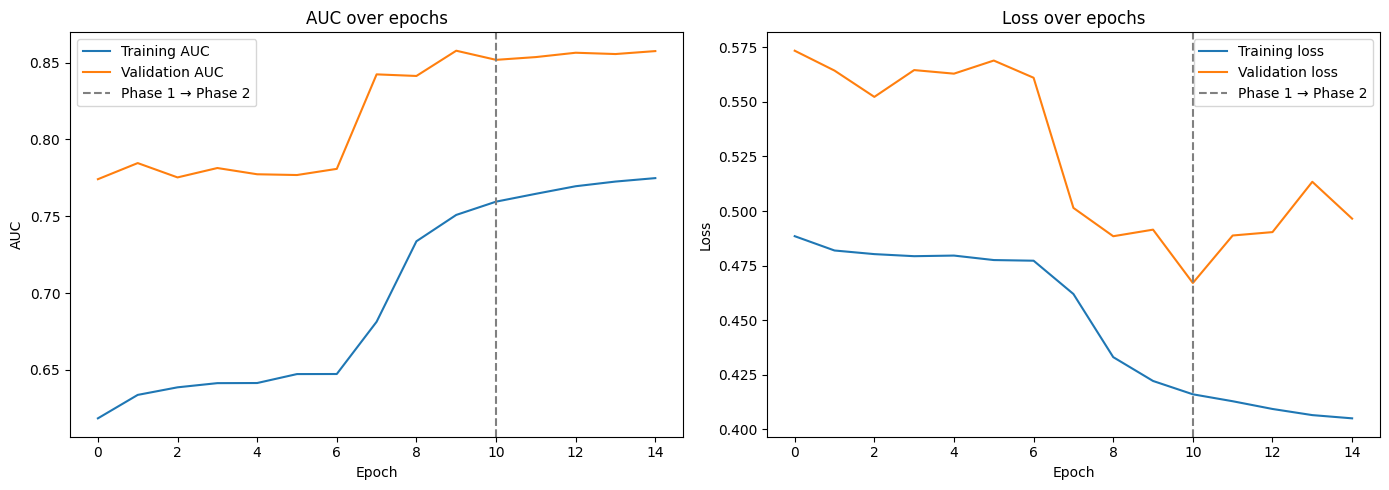

In [28]:
from IPython.display import Image, display

if history_data is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history_data['auc'], label='Training AUC')
    axes[0].plot(history_data['val_auc'], label='Validation AUC')
    # Mark the transition between phase 1 and phase 2
    if len(history_data['auc']) > 10:
        axes[0].axvline(x=10, color='gray', linestyle='--', label='Phase 1 → Phase 2')
    axes[0].set_title('AUC over epochs')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('AUC')
    axes[0].legend()

    axes[1].plot(history_data['loss'], label='Training loss')
    axes[1].plot(history_data['val_loss'], label='Validation loss')
    if len(history_data['loss']) > 10:
        axes[1].axvline(x=10, color='gray', linestyle='--', label='Phase 1 → Phase 2')
    axes[1].set_title('Loss over epochs')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()

    plt.tight_layout()
    plt.savefig('../results/figures/densenet_training.png')
    plt.show()
else:
    display(Image(filename='../results/figures/densenet_training.png'))

## 8. Evaluate the model

We evaluate DenseNet121 on the validation set and compare against:
- Our baseline CNN from notebook 02 (Mean AUC: 0.865)
- Stanford baseline ensemble (Mean AUC: 0.907, Irvin et al., 2019)

In [29]:
from sklearn.metrics import roc_auc_score

# Get predictions
y_pred = model.predict(valid_ds)
y_true = np.concatenate([y for _, y in valid_ds], axis=0)

# AUC per condition
print("--- AUC per condition ---")
for i, label in enumerate(LABELS):
    auc = roc_auc_score(y_true[:, i], y_pred[:, i])
    print(f"{label}: {auc:.4f}")

# Mean AUC
mean_auc = roc_auc_score(y_true, y_pred, average='macro')
print(f"\n--- Model comparison ---")
print(f"Baseline CNN (notebook 02):  0.8653")
print(f"DenseNet121  (this notebook): {mean_auc:.4f}")
print(f"Stanford baseline:            0.9070")

7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 889ms/step
--- AUC per condition ---
Atelectasis: 0.7808
Cardiomegaly: 0.7956
Consolidation: 0.8610
Edema: 0.9238
Pleural Effusion: 0.9243

--- Model comparison ---
Baseline CNN (notebook 02):  0.8653
DenseNet121  (this notebook): 0.8571
Stanford baseline:            0.9070


## 9. AUC per condition - Model comparison

Visual comparison of Baseline CNN vs DenseNet121 across all 5 conditions.
DenseNet121 outperforms the Baseline CNN on Edema and Pleural Effusion,
while the Baseline CNN performs better on Atelectasis and Cardiomegaly.

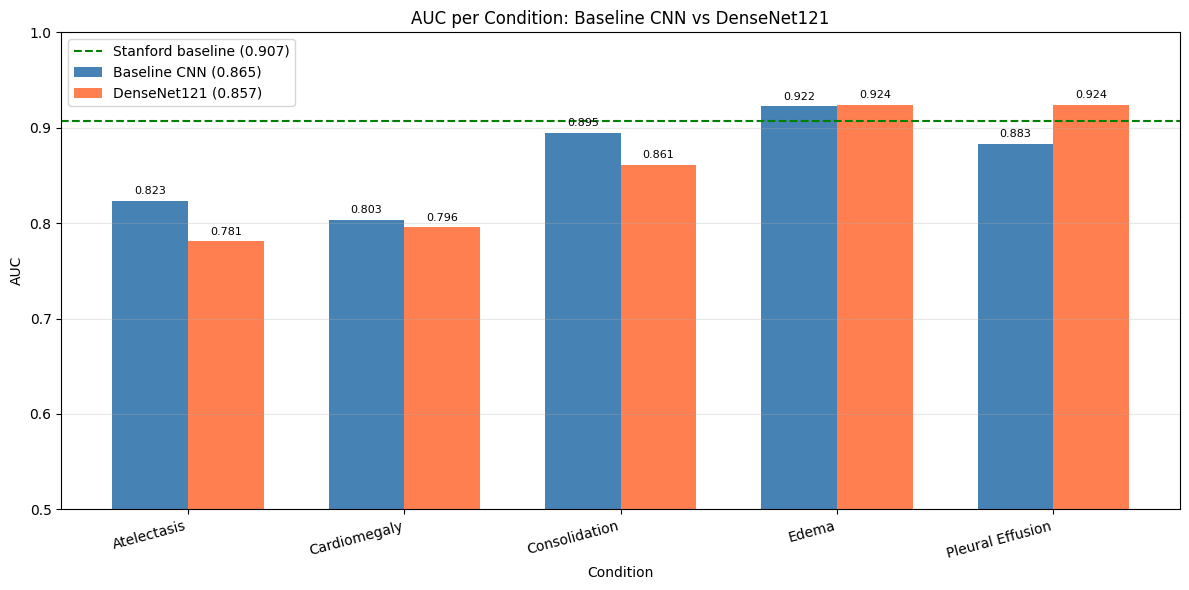

In [30]:
conditions = LABELS
baseline_auc = [0.8230, 0.8031, 0.8947, 0.9223, 0.8833]
densenet_auc = [
    roc_auc_score(y_true[:, i], y_pred[:, i])
    for i in range(len(LABELS))
]

x = np.arange(len(conditions))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, baseline_auc, width, label='Baseline CNN (0.865)', color='steelblue')
bars2 = ax.bar(x + width/2, densenet_auc, width, label=f'DenseNet121 ({np.mean(densenet_auc):.3f})', color='coral')
ax.axhline(y=0.907, color='green', linestyle='--', label='Stanford baseline (0.907)')

for bar, auc in zip(bars1, baseline_auc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{auc:.3f}', ha='center', va='bottom', fontsize=8)
for bar, auc in zip(bars2, densenet_auc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{auc:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Condition')
ax.set_ylabel('AUC')
ax.set_title('AUC per Condition: Baseline CNN vs DenseNet121')
ax.set_xticks(x)
ax.set_xticklabels(conditions, rotation=15, ha='right')
ax.legend()
ax.set_ylim(0.5, 1.0)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../results/figures/model_comparison.png')
plt.show()

## 10. Precision, Recall and F1-score

In addition to AUC, we compute precision, recall and F1-score at a
classification threshold of 0.5 to provide a more complete evaluation
of model performance per condition.

In [31]:
from sklearn.metrics import precision_score, recall_score, f1_score

y_pred_binary = (y_pred >= 0.5).astype(int)

print("--- Precision, Recall and F1-score - DenseNet121 ---")
for i, label in enumerate(LABELS):
    precision = precision_score(y_true[:, i], y_pred_binary[:, i], zero_division=0)
    recall = recall_score(y_true[:, i], y_pred_binary[:, i], zero_division=0)
    f1 = f1_score(y_true[:, i], y_pred_binary[:, i], zero_division=0)
    print(f"{label}: Precision={precision:.4f}  Recall={recall:.4f}  F1={f1:.4f}")

print(f"\nMacro averages:")
print(f"  Precision: {precision_score(y_true, y_pred_binary, average='macro', zero_division=0):.4f}")
print(f"  Recall:    {recall_score(y_true, y_pred_binary, average='macro', zero_division=0):.4f}")
print(f"  F1-score:  {f1_score(y_true, y_pred_binary, average='macro', zero_division=0):.4f}")

--- Precision, Recall and F1-score - DenseNet121 ---
Atelectasis: Precision=0.5926  Recall=0.2133  F1=0.3137
Cardiomegaly: Precision=1.0000  Recall=0.0152  F1=0.0299
Consolidation: Precision=0.0000  Recall=0.0000  F1=0.0000
Edema: Precision=0.6905  Recall=0.6905  F1=0.6905
Pleural Effusion: Precision=0.7458  Recall=0.6875  F1=0.7154

Macro averages:
  Precision: 0.6058
  Recall:    0.3213
  F1-score:  0.3499


## 11. Threshold tuning

A fixed threshold of 0.5 may not be optimal for all conditions.
We search for the optimal threshold per condition that maximizes F1-score.

In [32]:
from sklearn.metrics import f1_score
import numpy as np

print("--- Optimal threshold per condition - DenseNet121 ---")
thresholds = np.arange(0.1, 0.9, 0.05)

for i, label in enumerate(LABELS):
    best_f1 = 0
    best_threshold = 0.5
    for t in thresholds:
        y_pred_t = (y_pred[:, i] >= t).astype(int)
        f1 = f1_score(y_true[:, i], y_pred_t, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = t
    print(f"{label}: best threshold={best_threshold:.2f}, F1={best_f1:.4f}")

--- Optimal threshold per condition - DenseNet121 ---
Atelectasis: best threshold=0.25, F1=0.6860
Cardiomegaly: best threshold=0.10, F1=0.5556
Consolidation: best threshold=0.10, F1=0.3830
Edema: best threshold=0.45, F1=0.7174
Pleural Effusion: best threshold=0.35, F1=0.7517


## References
- Chollet, F. (2025). *Deep Learning with Python*, 3rd edition. Manning Publications.
- Irvin, J. et al. (2019). CheXpert: A Large Chest Radiograph Dataset with Uncertainty Labels and Expert Comparison. *AAAI*. https://arxiv.org/abs/1901.07031